In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Normal data (cluster)
np.random.seed(42)
X_normal = np.random.multivariate_normal(
    mean=[14, 15],
    cov=[[2, 0.5], [0.5, 2]],
    size=300
)

# Add anomalies (far away points)
X_anomaly = np.array([
    [5, 25], [25, 5], [22, 4], [4, 22], [20, 20]
])

# Combine dataset
X = np.vstack([X_normal, X_anomaly])

# Labels (for validation only)
y = np.hstack([np.zeros(300), np.ones(len(X_anomaly))])

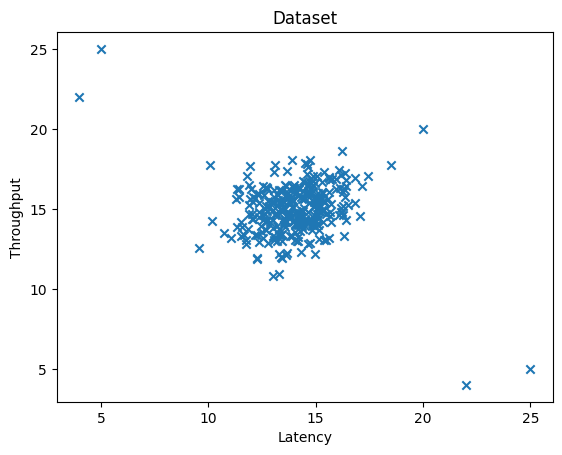

In [4]:
plt.scatter(X[:, 0], X[:, 1], marker='x')
plt.xlabel("Latency")
plt.ylabel("Throughput")
plt.title("Dataset")
plt.show()

In [5]:
def estimate_gaussian(X):
    m = X.shape[0]

    mu = np.sum(X, axis=0) / m
    var = np.sum((X - mu) ** 2, axis=0) / m

    return mu, var


mu, var = estimate_gaussian(X)
print("Mean:", mu)
print("Variance:", var)

Mean: [14.04537751 15.00129243]
Variance: [3.20327223 3.13290424]


In [6]:
def multivariate_gaussian(X, mu, var):
    n = len(mu)
    var_matrix = np.diag(var)

    X = X - mu

    coeff = (2 * np.pi) ** (-n / 2) * (np.linalg.det(var_matrix) ** -0.5)
    exp_term = np.exp(-0.5 * np.sum((X @ np.linalg.inv(var_matrix)) * X, axis=1))

    return coeff * exp_term


p = multivariate_gaussian(X, mu, var)

/tmp/ipykernel_6439/1945209583.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] = multivariate_gaussian(point, mu, var)


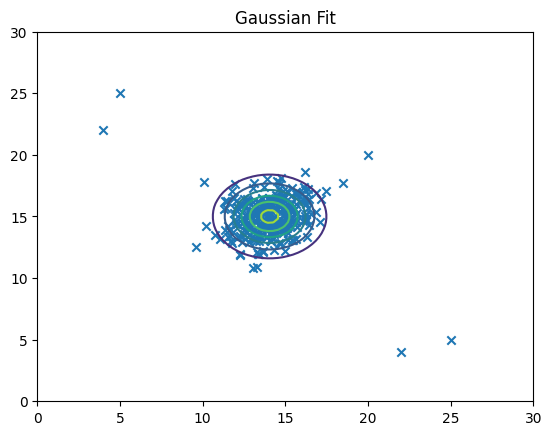

In [7]:
def plot_contours(X, mu, var):
    x = np.linspace(0, 30, 100)
    y = np.linspace(0, 30, 100)
    X_grid, Y_grid = np.meshgrid(x, y)

    Z = np.zeros(X_grid.shape)

    for i in range(X_grid.shape[0]):
        for j in range(X_grid.shape[1]):
            point = np.array([[X_grid[i, j], Y_grid[i, j]]])
            Z[i, j] = multivariate_gaussian(point, mu, var)

    plt.contour(X_grid, Y_grid, Z)
    plt.scatter(X[:, 0], X[:, 1], marker='x')
    plt.title("Gaussian Fit")
    plt.show()


plot_contours(X, mu, var)

In [8]:
def select_threshold(y, p):
    best_epsilon = 0
    best_F1 = 0

    step = (p.max() - p.min()) / 1000

    for epsilon in np.arange(p.min(), p.max(), step):

        predictions = (p < epsilon)

        tp = np.sum((predictions == 1) & (y == 1))
        fp = np.sum((predictions == 1) & (y == 0))
        fn = np.sum((predictions == 0) & (y == 1))

        if tp + fp == 0 or tp + fn == 0:
            continue

        precision = tp / (tp + fp)
        recall = tp / (tp + fn)

        if precision + recall == 0:
            continue

        F1 = 2 * precision * recall / (precision + recall)

        if F1 > best_F1:
            best_F1 = F1
            best_epsilon = epsilon

    return best_epsilon, best_F1


epsilon, F1 = select_threshold(y, p)

print("Best epsilon:", epsilon)
print("Best F1 score:", F1)

Best epsilon: 5.016477447290961e-05
Best F1 score: 1.0


In [9]:
outliers = p < epsilon

print("Number of anomalies:", np.sum(outliers))

Number of anomalies: 5


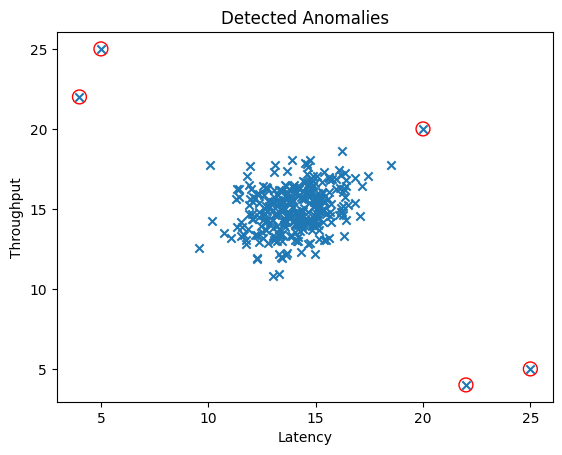

In [10]:
plt.scatter(X[:, 0], X[:, 1], marker='x')
plt.scatter(X[outliers, 0], X[outliers, 1],
            facecolors='none', edgecolors='r', s=100)

plt.title("Detected Anomalies")
plt.xlabel("Latency")
plt.ylabel("Throughput")
plt.show()

In [11]:
def find_closest_centroids(X, centroids):
    m = X.shape[0]
    K = centroids.shape[0]

    idx = np.zeros(m, dtype=int)

    for i in range(m):
        distances = []

        for j in range(K):
            dist = np.linalg.norm(X[i] - centroids[j])
            distances.append(dist)

        idx[i] = np.argmin(distances)

    return idx

In [12]:
def compute_centroids(X, idx, K):
    m, n = X.shape
    centroids = np.zeros((K, n))

    for k in range(K):
        points = X[idx == k]

        if len(points) > 0:
            centroids[k] = np.mean(points, axis=0)

    return centroids

In [13]:
def run_kmeans(X, initial_centroids, max_iters=10):
    centroids = initial_centroids

    for i in range(max_iters):
        print(f"Iteration {i+1}/{max_iters}")

        # Step 1: Assign clusters
        idx = find_closest_centroids(X, centroids)

        # Step 2: Update centroids
        centroids = compute_centroids(X, idx, centroids.shape[0])

    return centroids, idx

In [14]:
def init_centroids(X, K):
    random_indices = np.random.permutation(X.shape[0])
    return X[random_indices[:K]]

In [15]:
K = 3
max_iters = 10

initial_centroids = init_centroids(X, K)

centroids, idx = run_kmeans(X, initial_centroids, max_iters)

Iteration 1/10
Iteration 2/10
Iteration 3/10
Iteration 4/10
Iteration 5/10
Iteration 6/10
Iteration 7/10
Iteration 8/10
Iteration 9/10
Iteration 10/10


In [18]:
from google.colab import files
uploaded = files.upload()

Saving Screenshot 2026-04-01 181508.png to Screenshot 2026-04-01 181508.png


In [19]:
original_img = plt.imread('Screenshot 2026-04-01 181508.png')

In [20]:
# reshape image
X_img = np.reshape(original_img, (-1, 3))

K = 16
max_iters = 10

initial_centroids = init_centroids(X_img, K)

centroids, idx = run_kmeans(X_img, initial_centroids, max_iters)

Iteration 1/10
Iteration 2/10
Iteration 3/10
Iteration 4/10
Iteration 5/10
Iteration 6/10
Iteration 7/10
Iteration 8/10
Iteration 9/10
Iteration 10/10


In [21]:
X_recovered = centroids[idx]
X_recovered = np.reshape(X_recovered, original_img.shape)

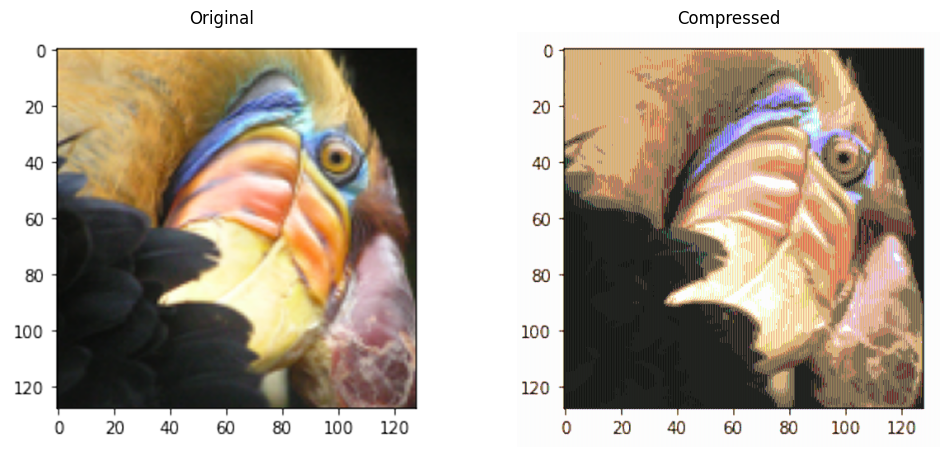

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(original_img)
ax[0].set_title("Original")

ax[1].imshow(X_recovered)
ax[1].set_title("Compressed")

for a in ax:
    a.axis('off')

plt.show()